# Final Project: End-to-End News Category Classification using DistilBERT

**Course:** DX703 - Advanced Machine Learning and AI  
**Team Members:** Jenny James, Sergey Nelyapanko, Lexi Fortuna  
**Date:** April, 26 2026  

**Objective:**  
This notebook implements a complete machine learning pipeline for classifying HuffPost news articles into 31 categories using both baseline and advanced deep learning models, culminating in a fine-tuned DistilBERT model.

## A.1: Setup and Context

### Problem Statement

This project addresses a multi-class text classification problem: automatically assigning news articles to one of 31 categories using headline and short description text.

### Dataset

We used the HuffPost News Category Dataset (~200K samples).

Key preprocessing steps:
- Merged overlapping categories (41 → 31)
- Removed duplicates and missing headlines
- Addressed class imbalance (29x skew)

### Summary of Milestones

**Milestone 1:**
- Data cleaning and category merging
- Exploratory data analysis (class imbalance, missing data)

**Milestone 2:**
- Implemented multiple models:
  - Baseline (Embedding + AvgPooling)
  - LSTM / BiLSTM
  - Enhanced baseline
  - DistilBERT (transfer learning)

**Key Insight:**
From-scratch models plateaued (~56% accuracy), while DistilBERT significantly improved performance (~71% accuracy).

### Imports + Config(Code)

In [2]:
#Special provision for colab!
if "google.colab" in sys.modules:
    !pip install "transformers<5" tf-keras tensorflow "huggingface_hub<0.28"
    import os
    os.environ["CUDA_VISIBLE_DEVICES"] = ""  # force CPU
    COLAB_CPU = True
else:
    # Kaggle / other environments: also need transformers<5 for TF support
    !pip install "transformers<5" tf-keras "huggingface_hub<0.28" -q
    COLAB_CPU = False

In [3]:
import os, time, json, gc, random
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from datasets import load_dataset
import requests
import json
from datasets import Dataset
import sys
import tensorflow as tf
from tensorflow import keras
import requests
import tf_keras

from sklearn.metrics import classification_report, accuracy_score, f1_score

from transformers import (
    AutoTokenizer,
    TFAutoModelForSequenceClassification,
    create_optimizer
)




# — Sergey: Metal GPU adds dispatch overhead on small models (Embedding+Dense),
#   making them ~10x slower. Set False for P2-P3, True for P4 (BERT).
USE_GPU = True

if USE_GPU:
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"GPU enabled: {len(gpus)} device(s)")
    else:
        print("No GPU found — CPU only")
else:
    tf.config.set_visible_devices([], 'GPU')
    print("GPU disabled (CPU mode)")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)
tf.random.set_seed(SEED)

def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))

GPU enabled: 1 device(s)


### Data Loading (Code)

In [4]:
URL = "https://huggingface.co/datasets/khalidalt/HuffPost/resolve/main/News_Category_Dataset_v2.json"
huff_all = load_dataset("json", data_files=URL, split="train")

print(huff_all)
print(f"Columns: {huff_all.column_names}")
print(f"Total samples: {len(huff_all):,}")

df = huff_all.to_pandas()
df.head(3)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


News_Category_Dataset_v2.json:   0%|          | 0.00/83.9M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Dataset({
    features: ['category', 'headline', 'authors', 'link', 'short_description', 'date'],
    num_rows: 200853
})
Columns: ['category', 'headline', 'authors', 'link', 'short_description', 'date']
Total samples: 200,853


,category,headline,authors,link,short_description,date
0,CRIME,There Were 2 Mass Shootings In Texas Last Week...,Melissa Jeltsen,https://www.huffingtonpost.com/entry/texas-ama...,She left her husband. He killed their children...,2018-05-26
1,ENTERTAINMENT,Will Smith Joins Diplo And Nicky Jam For The 2...,Andy McDonald,https://www.huffingtonpost.com/entry/will-smit...,Of course it has a song.,2018-05-26
2,ENTERTAINMENT,Hugh Grant Marries For The First Time At Age 57,Ron Dicker,https://www.huffingtonpost.com/entry/hugh-gran...,The actor and his longtime girlfriend Anna Ebe...,2018-05-26


In [5]:
## special loading for colab
URL = "https://huggingface.co/datasets/khalidalt/HuffPost/resolve/main/News_Category_Dataset_v2.json"

# download file
response = requests.get(URL)
data = [json.loads(line) for line in response.text.splitlines()]

# convert to Hugging Face dataset
huff_all = Dataset.from_list(data)

print(huff_all)
print(f"Columns: {huff_all.column_names}")
print(f"Total samples: {len(huff_all):,}")

df = huff_all.to_pandas()
df.head(3)

Dataset({
    features: ['category', 'headline', 'authors', 'link', 'short_description', 'date'],
    num_rows: 200853
})
Columns: ['category', 'headline', 'authors', 'link', 'short_description', 'date']
Total samples: 200,853


,category,headline,authors,link,short_description,date
0,CRIME,There Were 2 Mass Shootings In Texas Last Week...,Melissa Jeltsen,https://www.huffingtonpost.com/entry/texas-ama...,She left her husband. He killed their children...,2018-05-26
1,ENTERTAINMENT,Will Smith Joins Diplo And Nicky Jam For The 2...,Andy McDonald,https://www.huffingtonpost.com/entry/will-smit...,Of course it has a song.,2018-05-26
2,ENTERTAINMENT,Hugh Grant Marries For The First Time At Age 57,Ron Dicker,https://www.huffingtonpost.com/entry/hugh-gran...,The actor and his longtime girlfriend Anna Ebe...,2018-05-26


### Final Preprocessing Pipeline

Steps:
- Merge categories
- Remove duplicates
- Handle missing descriptions
- Combine headline + description

In [6]:
# Merge confusable categories identified in Milestone 1
LABEL_MAP = {
    "ARTS & CULTURE": "ARTS", "CULTURE & ARTS": "ARTS",
    "THE WORLDPOST": "WORLD NEWS", "WORLDPOST": "WORLD NEWS",
    "PARENTS": "PARENTING",
    "STYLE & BEAUTY": "STYLE",
    "TASTE": "FOOD & DRINK",
    "GREEN": "ENVIRONMENT",
    "COLLEGE": "EDUCATION",
    "HEALTHY LIVING": "HOME & LIVING",
}

print(f"Before merge: {df['category'].nunique()} categories, {len(df):,} rows")

df["category"] = df["category"].replace(LABEL_MAP)

# Combine headline + description
df["text"] = df.apply(
    lambda r: (r["headline"] + " [SEP] " + r["short_description"]).strip()
    if pd.notna(r["short_description"]) and r["short_description"].strip()
    else r["headline"],
    axis=1,
)

# Drop empty headlines
empty_mask = df["headline"].isna() | (df["headline"].str.strip() == "")
print(f"Empty headlines dropped: {empty_mask.sum()}")
df = df[~empty_mask].copy()

# Remove exact duplicates (headline + short_description)
before_dedup = len(df)
df = df.drop_duplicates(subset=["headline", "short_description"], keep="first")
print(f"Duplicates removed: {before_dedup - len(df)}")

print(f"After cleaning: {df['category'].nunique()} categories, {len(df):,} rows")

Before merge: 41 categories, 200,853 rows
Empty headlines dropped: 6
Duplicates removed: 484
After cleaning: 31 categories, 200,363 rows


### Class Distribution

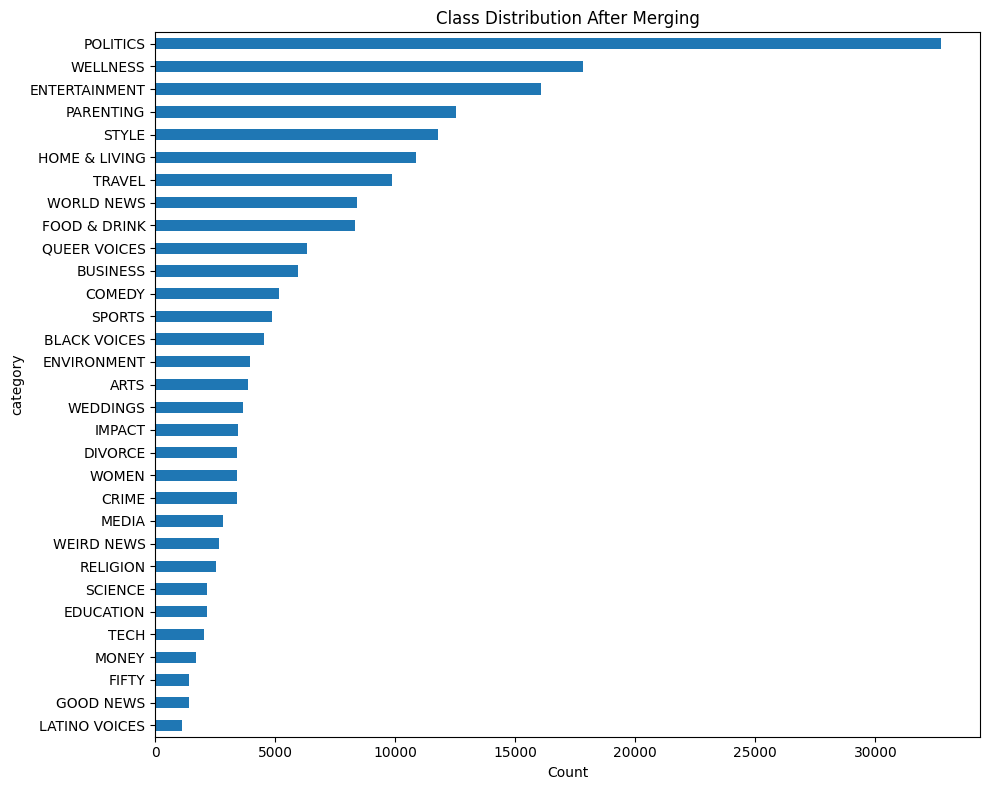

Categories: 31
Largest:  POLITICS (32,721)
Smallest: LATINO VOICES (1,129)
Median:   3,876
Imbalance ratio (max/min): 29.0x


In [7]:
counts = df["category"].value_counts()

fig, ax = plt.subplots(figsize=(10, 8))
counts.plot.barh(ax=ax)
ax.set_xlabel("Count")
ax.set_title("Class Distribution After Merging")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(f"Categories: {len(counts)}")
print(f"Largest:  {counts.index[0]} ({counts.iloc[0]:,})")
print(f"Smallest: {counts.index[-1]} ({counts.iloc[-1]:,})")
print(f"Median:   {int(counts.median()):,}")
print(f"Imbalance ratio (max/min): {counts.iloc[0] / counts.iloc[-1]:.1f}x")

### Stratified Train / Val / Test Splits

In [8]:
texts = np.array(df["text"].tolist(), dtype=object)
labels = df["category"].tolist()

# Encode labels
class_names = sorted(set(labels))
label2id = {name: i for i, name in enumerate(class_names)}
y = np.array([label2id[c] for c in labels])
num_classes = len(class_names)

X_train, X_temp, y_train, y_temp = train_test_split(
    texts,
    y,
    test_size=0.20,
    stratify=y,
    random_state=SEED
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=SEED
)

print("Train size:", len(X_train))
print("Val size:", len(X_val))
print("Test size:", len(X_test))

print(f"Train: {len(X_train):,}  Val: {len(X_val):,}  Test: {len(X_test):,}")
print(f"Classes: {num_classes}")

# Compute class weights for imbalanced training
cw = compute_class_weight("balanced", classes=np.arange(num_classes), y=y_train)
class_weights = dict(enumerate(cw))
print(f"Class weight range: [{min(cw):.3f}, {max(cw):.3f}]")

Train size: 160290
Val size: 20036
Test size: 20037
Train: 160,290  Val: 20,036  Test: 20,037
Classes: 31
Class weight range: [0.198, 5.726]


### Text Length Distribution

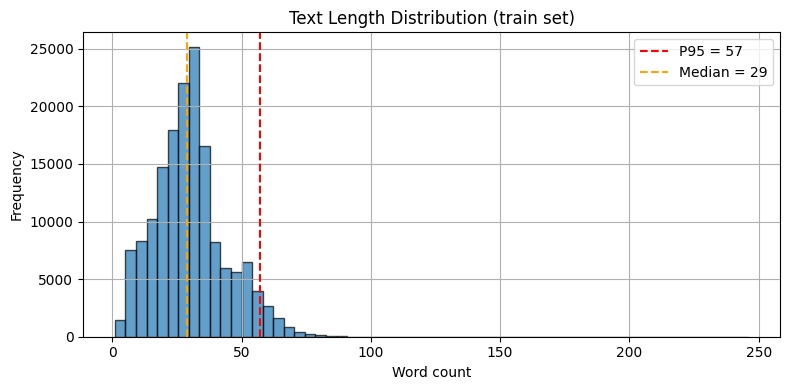

Mean:   30.2
Median: 29
P95:    57
P99:    68
Max:    246


In [9]:
word_counts = pd.Series([len(t.split()) for t in X_train])

fig, ax = plt.subplots(figsize=(8, 4))
word_counts.hist(bins=60, ax=ax, edgecolor="black", alpha=0.7)
ax.axvline(word_counts.quantile(0.95), color="red", ls="--", label=f"P95 = {word_counts.quantile(0.95):.0f}")
ax.axvline(word_counts.median(), color="orange", ls="--", label=f"Median = {word_counts.median():.0f}")
ax.set_xlabel("Word count")
ax.set_ylabel("Frequency")
ax.set_title("Text Length Distribution (train set)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Mean:   {word_counts.mean():.1f}")
print(f"Median: {word_counts.median():.0f}")
print(f"P95:    {word_counts.quantile(0.95):.0f}")
print(f"P99:    {word_counts.quantile(0.99):.0f}")
print(f"Max:    {word_counts.max()}")

## A.2: Model Selection and Retraining

### Final Model Selection

DistilBERT was selected as the final model because:
- Highest test accuracy (0.708)
- Highest macro F1 (0.621)
- Strong performance across all categories

From-scratch models failed to exceed ~56% accuracy, indicating limitations in representation learning.

#### Defining the needed functions to be used

In [10]:
from sklearn.metrics import classification_report, f1_score, confusion_matrix

RESULTS_FILE = "results/ms2_results.json"
results = {}

def save_results():
    os.makedirs(os.path.dirname(RESULTS_FILE), exist_ok=True)
    with open(RESULTS_FILE, "w") as f:
        json.dump(results, f, indent=2)
    print(f"Results saved ({len(results)} models)")

def load_results():
    global results
    try:
        with open(RESULTS_FILE) as f:
            results = json.load(f)
        if results:
            print(f"Restored {len(results)} results from {RESULTS_FILE}:")
            for name, r in results.items():
                print(f"  {name}: test_acc={r['test_acc']:.4f}, test_f1={r['test_f1']:.4f}")
    except FileNotFoundError:
        pass

def evaluate_model(model, name, X_te, y_te, hist, train_time, batch_size=512):
    preds = model.predict(X_te, batch_size=batch_size, verbose=0)

    # Handle Hugging Face TF models that return an object with `.logits`
    if hasattr(preds, "logits"):
        y_pred = np.argmax(preds.logits, axis=-1)
    else:
        y_pred = np.argmax(preds, axis=-1)

    test_acc = float(np.mean(y_pred == y_te))
    test_f1 = float(f1_score(y_te, y_pred, average="macro"))

    val_losses = hist.history["val_loss"]
    best_epoch = int(np.argmin(val_losses)) + 1
    val_acc = float(hist.history["val_accuracy"][best_epoch - 1])
    val_loss = float(val_losses[best_epoch - 1])

    results[name] = {
        "val_acc": val_acc,
        "val_loss": val_loss,
        "best_epoch": best_epoch,
        "test_acc": test_acc,
        "test_f1": test_f1,
        "params": model.count_params(),
        "train_time": train_time,
    }
    save_results()
    return y_pred

# Auto-restore on cell run
load_results()

#### Saving the confusion matrix confused pairs to a file as well for reporting later

In [11]:
def save_confused_pairs(confused,model_name, top_n=10):

    confused.sort(reverse=True)
    file_path="confused_pairs.csv"
    if top_n is not None:
        confused = confused[:top_n]

    new_df = pd.DataFrame(
        confused,
        columns=["Count", "True Label", "Predicted Label"]
    )
    new_df["Model"] = model_name
    new_df = new_df[["Model", "Count", "True Label", "Predicted Label"]]

    file_exists = os.path.exists(file_path)

    new_df.to_csv(
        file_path,
        mode="a",
        header=not file_exists,
        index=False
    )

    return new_df

### Learning Curves & Evaluation functions

In [12]:
def plot_learning_curves(hist, title):
    val_losses = hist.history["val_loss"]
    min_val_loss = min(val_losses)
    best_epoch = val_losses.index(min_val_loss)
    val_acc_best = hist.history["val_accuracy"][best_epoch]

    epochs = range(1, len(val_losses) + 1)
    fig, axs = plt.subplots(2, 1, figsize=(8, 7), sharex=True)

    axs[0].plot(epochs, hist.history["loss"], label="train")
    axs[0].plot(epochs, val_losses, label="val")
    axs[0].scatter(best_epoch + 1, min_val_loss, color="red", marker="x", s=60, label="best")
    axs[0].set_title(f"{title} — Loss")
    axs[0].set_ylabel("Loss")
    axs[0].legend()
    axs[0].grid(True)

    axs[1].plot(epochs, hist.history["accuracy"], label="train")
    axs[1].plot(epochs, hist.history["val_accuracy"], label="val")
    axs[1].scatter(best_epoch + 1, val_acc_best, color="red", marker="x", s=60, label="best")
    axs[1].set_title(f"{title} — Accuracy")
    axs[1].set_xlabel("Epoch")
    axs[1].set_ylabel("Accuracy")
    axs[1].legend()
    axs[1].grid(True)

    plt.tight_layout()
    plt.show()

    print(f"Best epoch: {best_epoch + 1}")
    print(f"Val loss:   {min_val_loss:.4f}")
    print(f"Val acc:    {val_acc_best:.4f}")
    return best_epoch + 1, val_acc_best

### Fastest BERT setup for HuffPost
Strategy:
- DistilBERT pretrained checkpoint
- Train on a subset first for speed
- Freeze most of backbone
- Unfreeze only top 2 transformer blocks
- Small LR for stability


### Hyperparameter Definitions

In [13]:
## Configure
checkpoint = "distilbert-base-uncased"
MAX_LEN = 64
BATCH = 128
EPOCHS = 16
LR = 2e-5           # small LR for partial fine-tuning
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.1
SUBSET_FRAC = 0.50  # fastest practical run; use 1.00 for final comparison

es = tf_keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

t0 = time.time()


#### Speed subset on training only

In [14]:


subset_frac = 0.50
n_train = len(X_train)
subset_size = int(n_train * subset_frac)

rng = np.random.default_rng(SEED)
subset_idx = rng.choice(n_train, size=subset_size, replace=False)

X_train_sub = X_train[subset_idx]
y_train_sub = y_train[subset_idx]

### Tokenization for distilBERT
#### Hugging Face recommends AutoTokenizer for sequence classification

In [15]:


tokenizer = AutoTokenizer.from_pretrained(checkpoint)

def tokenize_texts(texts, tokenizer, max_length=64):
    return tokenizer(
        list(texts),
        truncation=True,
        padding="max_length",
        max_length=max_length,
        return_tensors="np"
    )

X_train_tok = tokenize_texts(X_train_sub, tokenizer, MAX_LEN)
X_val_tok   = tokenize_texts(X_val, tokenizer, MAX_LEN)
X_test_tok  = tokenize_texts(X_test, tokenizer, MAX_LEN)

y_train_final = y_train_sub
y_val_final   = y_val
y_test_final  = y_test

print("Train token shapes:", {k: v.shape for k, v in X_train_tok.items()})
print("Train labels shape:", y_train_final.shape)
print("Val labels shape:", y_val_final.shape)
print("Test labels shape:", y_test_final.shape)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Train token shapes: {'input_ids': (80145, 64), 'attention_mask': (80145, 64)}
Train labels shape: (80145,)
Val labels shape: (20036,)
Test labels shape: (20037,)


In [16]:
## tf.data pipelines

AUTOTUNE = tf.data.AUTOTUNE

train_ds = tf.data.Dataset.from_tensor_slices((
    dict(X_train_tok),
    y_train_final
)).shuffle(len(y_train_final), seed=SEED).batch(BATCH).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((
    dict(X_val_tok),
    y_val_final
)).batch(BATCH).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((
    dict(X_test_tok),
    y_test_final
)).batch(BATCH).prefetch(tf.data.AUTOTUNE)

### Class weights for imbalance for distilBERT

In [17]:


from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train_final)
class_weights_arr = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_final
)
class_weights = {int(c): float(w) for c, w in zip(classes, class_weights_arr)}
print("Class weights:", class_weights)


Class weights: {0: 1.657258064516129, 1: 1.4370887051946422, 2: 1.0973355605454844, 3: 1.2495517547825816, 4: 1.9178950894993778, 5: 1.933674331073419, 6: 2.934531873604042, 7: 0.40662513064566863, 8: 1.6239463446263576, 9: 4.633194588969823, 10: 0.7805925666199158, 11: 4.616647465437788, 12: 0.5976242673705875, 13: 1.8707109845478735, 14: 5.632511068943707, 15: 2.28587319243604, 16: 3.7252486752812124, 17: 0.5141850796828086, 18: 0.19624431308981033, 19: 1.0333023903457879, 20: 2.5775898112115265, 21: 2.8193266964505574, 22: 1.3423274042809767, 23: 0.545772130176306, 24: 3.126145804891368, 25: 0.6445581103578063, 26: 1.7270023918805353, 27: 2.402716153015949, 28: 0.37044312661486767, 29: 1.8400872460107909, 30: 0.7738169951048073}


#### Load pretrained DistilBERT model

In [18]:


id2label = {i: name for name, i in label2id.items()}

p4_model = TFAutoModelForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=num_classes,
    id2label=id2label,
    label2id=label2id
)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertForSequenceClassification: ['vocab_layer_norm.bias', 'vocab_transform.bias', 'vocab_layer_norm.weight', 'vocab_projector.bias', 'vocab_transform.weight']
- This IS expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFDistilBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['pre_classifier.weight', 'pre_classifier.bias', 'classifier.weight', 'classifier.bias']
You should 

### Learning strategy - Freeze most of backbone, unfreeze only top 2 blocks

In [19]:

## In TF/Keras, setting parent.trainable=False overrides children.
## Must freeze individual layers, NOT the parent model.

p4_model.distilbert.trainable = True  # keep parent trainable so children are respected

# Freeze the embedding layer
p4_model.distilbert.embeddings.trainable = False

# Freeze all transformer blocks first, then unfreeze top 2
for layer in p4_model.distilbert.transformer.layer:
    layer.trainable = False
for layer in p4_model.distilbert.transformer.layer[-2:]:
    layer.trainable = True

# Ensure classification head remains trainable
if hasattr(p4_model, "pre_classifier"):
    p4_model.pre_classifier.trainable = True
if hasattr(p4_model, "classifier"):
    p4_model.classifier.trainable = True
if hasattr(p4_model, "dropout"):
    p4_model.dropout.trainable = True

# Optional: inspect trainable variables
_ = p4_model(p4_model.dummy_inputs)  # build model once

print("\nTrainable variables:")
for v in p4_model.trainable_variables[:20]:
    print(v.name, v.shape)
print("Total trainable vars:", len(p4_model.trainable_variables))


Trainable variables:
tf_distil_bert_for_sequence_classification/distilbert/transformer/layer_._4/attention/q_lin/kernel:0 (768, 768)
tf_distil_bert_for_sequence_classification/distilbert/transformer/layer_._4/attention/q_lin/bias:0 (768,)
tf_distil_bert_for_sequence_classification/distilbert/transformer/layer_._4/attention/k_lin/kernel:0 (768, 768)
tf_distil_bert_for_sequence_classification/distilbert/transformer/layer_._4/attention/k_lin/bias:0 (768,)
tf_distil_bert_for_sequence_classification/distilbert/transformer/layer_._4/attention/v_lin/kernel:0 (768, 768)
tf_distil_bert_for_sequence_classification/distilbert/transformer/layer_._4/attention/v_lin/bias:0 (768,)
tf_distil_bert_for_sequence_classification/distilbert/transformer/layer_._4/attention/out_lin/kernel:0 (768, 768)
tf_distil_bert_for_sequence_classification/distilbert/transformer/layer_._4/attention/out_lin/bias:0 (768,)
tf_distil_bert_for_sequence_classification/distilbert/transformer/layer_._4/sa_layer_norm/gamma:0 (768

#### Optimizer / LR schedule for distilBERT

In [20]:

## Smaller LR for partial fine-tuning

import math
steps_per_epoch = math.ceil(len(y_train_final) / BATCH)
num_train_steps = steps_per_epoch * EPOCHS
num_warmup_steps = int(WARMUP_RATIO * num_train_steps)

optimizer, lr_schedule = create_optimizer(
    init_lr=LR,
    num_train_steps=num_train_steps,
    num_warmup_steps=num_warmup_steps,
    weight_decay_rate=WEIGHT_DECAY,
)

p4_model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)


### Train the model

In [ ]:
import tf_keras


history = p4_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=[es],
    verbose=1
)

train_time = time.time() - t0
print(f"\nTraining time: {train_time/60:.2f} minutes")



Epoch 1/16
 22/627 [>.............................] - ETA: 3:54 - loss: 3.4034 - accuracy: 0.0174

## A.3: Evaluation and Visualization

### Evaluation Strategy

- Train: model learning
- Validation: model selection
- Test: final evaluation

Metrics:
- Accuracy
- Macro F1 (primary metric due to class imbalance)

### Metrics and Classification Report

In [ ]:
## -------------------------------------------------------------------
val_logits = p4_model.predict(val_ds).logits
test_logits = p4_model.predict(test_ds).logits

val_pred = np.argmax(val_logits, axis=1)
test_pred = np.argmax(test_logits, axis=1)

val_acc = accuracy_score(y_val_final, val_pred)
val_f1_macro = f1_score(y_val_final, val_pred, average="macro")
val_f1_weighted = f1_score(y_val_final, val_pred, average="weighted")

test_acc = accuracy_score(y_test_final, test_pred)
test_f1_macro = f1_score(y_test_final, test_pred, average="macro")
test_f1_weighted = f1_score(y_test_final, test_pred, average="weighted")

print("\nValidation metrics")
print("Accuracy:", round(val_acc, 4))
print("Macro F1:", round(val_f1_macro, 4))
print("Weighted F1:", round(val_f1_weighted, 4))

print("\nTest metrics")
print("Accuracy:", round(test_acc, 4))
print("Macro F1:", round(test_f1_macro, 4))
print("Weighted F1:", round(test_f1_weighted, 4))

print("\nClassification report (test)")
print(classification_report(
    y_test_final,
    test_pred,
    target_names=[id2label[i] for i in range(num_classes)],
    digits=4
))

##----------------------------------------------
from sklearn.metrics import balanced_accuracy_score, confusion_matrix

print("\nBalanced Accuracy")
print("Validation:", round(balanced_accuracy_score(y_val_final, val_pred), 4))
print("Test:", round(balanced_accuracy_score(y_test_final, test_pred), 4))

cm = confusion_matrix(y_test_final, test_pred)
print("\nConfusion matrix shape:", cm.shape)

### Training Curves

In [ ]:
best_ep, val_acc = plot_learning_curves(history, "distilBERT")

In [ ]:
y_pred_distilbert = evaluate_model(
    model=p4_model,
    name="DistilBERT",
    X_te=test_ds,
    y_te=y_test_final,
    hist=history,
    train_time=train_time,
    batch_size=BATCH
)

### Confusion Matrix

In [ ]:


cm = confusion_matrix(y_test_final, y_pred_distilbert)

confused = []
for i in range(num_classes):
    for j in range(num_classes):
        if i != j and cm[i, j] > 0:
            confused.append((cm[i, j], class_names[i], class_names[j]))
confused.sort(reverse=True)

print("Top 10 confused pairs (true -> predicted, count):")
# for count, true, pred in confused[:10]:
#     print(f"  {true:25s} -> {pred:25s}  ({count})”)

save_confused_pairs(confused,model_name="distilBERT", top_n=10)

### Final Results

- Test Accuracy: 0.708
- Macro F1: 0.621

Key Observations:
- DistilBERT outperformed all baseline models
- Strong performance across all categories
- Reduced confusion in POLITICS vs WORLD NEWS